# 01 — AC Power Flow from Scratch, and the Linear System Hiding Inside It

**Learned Iterative Solvers for AC Power Flow** · Notebook 1 of a series

---

Everything in this project is about replacing one specific computation with a learned
one. Before we can do that honestly, we need to know exactly which computation, how much
it costs, and how good the classical alternatives already are. That is this notebook.

We do three things:

1. Build AC power flow Newton–Raphson from scratch and **validate it to machine
   precision** against `pandapower`.
2. Open up the Newton step and look at the linear system $\mathbf{J}\,\Delta x = -\mathbf{f}$
   that consumes essentially all of the work.
3. Solve that linear system three ways — sparse LU, GMRES, and preconditioned GMRES —
   and plot how much accuracy is available at each Krylov subspace dimension.

The final figure of this notebook is the object that later notebooks will try to learn.

### References

| | |
|---|---|
| **[1]** | Monga, Li & Eldar, *Algorithm Unrolling*, IEEE SPM 38(2), 2021 |
| **[2]** | Gregor & LeCun, *Learning Fast Approximations of Sparse Coding*, ICML 2010 |
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[4]** | Guo, Dietrich, Bertalan, Doncevic, Dahmen, Kevrekidis & Li, *Personalized Algorithm Generation: Learning ODE Integrators*, SIAM J. Sci. Comput. 44(4), 2022 |
| **[5]** | Doncevic, Mitsos, Guo, Li, Dietrich, Dahmen & Kevrekidis, *A Recursively Recurrent Neural Network (R2N2) Architecture for Learning Iterative Algorithms*, SIAM J. Sci. Comput. 46(2), 2024 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

from lis import load_case, newton_pf, build_ybus, build_jacobian, mismatch
from lis.krylov import arnoldi, gmres, ilu_preconditioner, lu_solve
from lis.plotting import use_style, save, annotate_tolerance, PALETTE, plt

use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=140)
print("ready")

ready

---
## 1. The problem

An AC power flow asks: given what every generator injects and every load draws, what are
the bus voltages? The unknowns are a magnitude and an angle per bus,

$$x = \big[\,\boldsymbol{\theta},\; |\mathbf{V}|\,\big],$$

and the equations are Kirchhoff's laws written as a **power balance** at each bus. In
complex form, the power injected at bus $i$ by the network is
$S_i = V_i \overline{\left(\sum_k Y_{ik} V_k\right)}$, so the residual we must drive to
zero is

$$\boxed{\;\mathbf{f}(x) \;=\; \mathbf{V} \odot \overline{\left(\mathbf{Y}_{bus}\mathbf{V}\right)} \;-\; \mathbf{S}^{spec} \;=\; \mathbf{0}\;}$$

Not every component of this is enforced, and this is where the bus types come in:

| Bus type | Known | Unknown | Equations enforced |
|---|---|---|---|
| **Slack** (`REF`, type 3) | $\vert V\vert,\ \theta$ | $P,\ Q$ | none |
| **PV** (type 2) | $P,\ \vert V\vert$ | $\theta,\ Q$ | $\Delta P$ only |
| **PQ** (type 1) | $P,\ Q$ | $\theta,\ \vert V\vert$ | $\Delta P$ and $\Delta Q$ |

So the real residual vector we actually solve is

$$\mathbf{f} = \begin{bmatrix} \Re\{\Delta\mathbf{S}\}_{[pv,\,pq]} \\ \Im\{\Delta\mathbf{S}\}_{[pq]} \end{bmatrix} \in \mathbb{R}^{n_{pv} + 2n_{pq}}$$

and the size of the Newton system is $n_{pv} + 2n_{pq}$ — noticeably smaller than $2n_{bus}$,
because slack contributes nothing and each PV bus contributes only its $P$ equation.

In [2]:
case = load_case("case14")
print(case)
print(f"\nslack : {case.ref}")
print(f"PV    : {case.pv}")
print(f"PQ    : {case.pq}")
print(f"\nNewton system size = n_pv + 2*n_pq = {len(case.pv)} + 2*{len(case.pq)} = {case.n_unknowns}")
print(f"(compare 2*n_bus = {2*case.n_bus})")

Case(case14: 14 buses, 20 branches, 1 slack / 4 PV / 9 PQ, n_unknowns=22)


slack : [0]

PV    : [1 2 5 7]

PQ    : [ 3  4  6  8  9 10 11 12 13]


Newton system size = n_pv + 2*n_pq = 4 + 2*9 = 22

(compare 2*n_bus = 28)

### 1.1 The case data is a MATPOWER case

`pandapower` is used here only as a *source of MATPOWER matrices*. After `runpp`, the
familiar tables are sitting in `net["_ppc"]` with exactly the columns you already read
fluently — so nothing below requires trusting a black box.

In [3]:
from pandapower.pypower.idx_bus import BUS_TYPE, PD, QD, GS, BS, VM, VA
from pandapower.pypower.idx_brch import F_BUS, T_BUS, BR_R, BR_X, BR_B, BR_G, TAP, SHIFT

bus_df = pd.DataFrame({
    "bus": case.bus[:, 0].astype(int),
    "type": np.where(case.bus[:, BUS_TYPE] == 3, "slack",
             np.where(case.bus[:, BUS_TYPE] == 2, "PV", "PQ")),
    "Pd [MW]": case.bus[:, PD], "Qd [MVAr]": case.bus[:, QD],
    "Gs": case.bus[:, GS], "Bs": case.bus[:, BS],
})
print("bus table (case14)"); display(bus_df.head(8))

br_df = pd.DataFrame({
    "from": case.branch[:, F_BUS].astype(int), "to": case.branch[:, T_BUS].astype(int),
    "r [pu]": case.branch[:, BR_R], "x [pu]": case.branch[:, BR_X],
    "b [pu]": case.branch[:, BR_B], "g [pu]": case.branch[:, BR_G],
    "tap": case.branch[:, TAP], "shift [deg]": case.branch[:, SHIFT],
})
print("\nbranch table (case14) — note the transformers at the bottom, tap != 1")
display(br_df.iloc[[0, 1, 2, 15, 16, 17]])

bus table (case14)

,bus,type,Pd [MW],Qd [MVAr],Gs,Bs
0,0,slack,0.0,0.0,0.0,0.0
1,1,PV,21.7,12.7,0.0,0.0
2,2,PV,94.2,19.0,0.0,0.0
3,3,PQ,47.8,-3.9,0.0,0.0
4,4,PQ,7.6,1.6,0.0,0.0
5,5,PV,11.2,7.5,0.0,0.0
6,6,PQ,0.0,0.0,0.0,0.0
7,7,PV,0.0,0.0,0.0,0.0



branch table (case14) — note the transformers at the bottom, tap != 1

,from,to,r [pu],x [pu],b [pu],g [pu],tap,shift [deg]
0,0,1,0.01938,0.05917,0.0528,0.0,1.000,0.0
1,0,4,0.05403,0.22304,0.0492,0.0,1.000,0.0
2,1,2,0.04699,0.19797,0.0438,0.0,1.000,0.0
15,3,6,0.00000,0.20912,-0.0000,0.0,0.978,0.0
16,3,8,0.00000,0.55618,-0.0000,0.0,0.969,0.0
17,4,5,0.00000,0.25202,-0.0000,0.0,0.932,0.0


---
## 2. The admittance matrix

Each branch is a $\pi$-model with series admittance $y_s = 1/(r+jx)$, total charging
admittance $y_c = g_c + jb_c$ split equally between the two ends, and an ideal
transformer of complex ratio $\tau = a\,e^{j\theta_{shift}}$ on the *from* side:

$$\begin{bmatrix} i_f \\ i_t \end{bmatrix} =
\begin{bmatrix} (y_s + y_c/2)/|\tau|^2 & -y_s/\bar{\tau} \\ -y_s/\tau & y_s + y_c/2 \end{bmatrix}
\begin{bmatrix} v_f \\ v_t \end{bmatrix}$$

Scattering these into the bus frame with the branch-to-bus connection matrices
$\mathbf{C}_f,\mathbf{C}_t$ and adding bus shunts gives

$$\mathbf{Y}_{bus} = \mathbf{C}_f^\top \mathbf{Y}_f + \mathbf{C}_t^\top \mathbf{Y}_t + \operatorname{diag}(\mathbf{y}_{sh})$$

> **A bug worth recording.** Classic MATPOWER carries only the susceptance $b_c$ in this
> model. The `BR_G` column — a branch shunt *conductance*, representing dielectric and
> corona losses — is a pandapower extension, and it is nonzero in `case118` and `case300`.
> Omitting it perturbs only the **real part of the $\mathbf{Y}_{bus}$ diagonal**, by about
> $10^{-5}$ relative. That is small enough to look like round-off, but it moves the
> converged voltages in the fifth decimal. It was caught only because the validation below
> demands *exact* agreement rather than "close enough".

In [4]:
rows = []
for name in ["case9", "case14", "case30", "case57", "case118", "case300"]:
    c = load_case(name)
    rows.append({
        "case": name, "buses": c.n_bus, "branches": c.n_branch,
        "slack/PV/PQ": f"{len(c.ref)}/{len(c.pv)}/{len(c.pq)}",
        "n_unknowns": c.n_unknowns,
        "Ybus nnz": c.ybus.nnz,
        "density [%]": 100 * c.ybus.nnz / c.n_bus**2,
        "max |dYbus| vs pandapower": np.abs(c.ybus - c.ybus_ref).max(),
    })
cases_df = pd.DataFrame(rows)
display(cases_df.style.format({"density [%]": "{:.2f}", "max |dYbus| vs pandapower": "{:.2e}"}))
print("Our Ybus is bit-for-bit identical to pandapower's on every case.")

,case,buses,branches,slack/PV/PQ,n_unknowns,Ybus nnz,density [%],max |dYbus| vs pandapower
0,case9,9,9,1/2/6,14,27,33.33,0.00e+00
1,case14,14,20,1/4/9,22,54,27.55,0.00e+00
2,case30,30,41,1/5/24,53,112,12.44,0.00e+00
3,case57,57,80,1/6/50,106,213,6.56,0.00e+00
4,case118,118,186,1/53/64,181,476,3.42,0.00e+00
5,case300,300,411,1/68/231,530,1118,1.24,0.00e+00


Our Ybus is bit-for-bit identical to pandapower's on every case.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


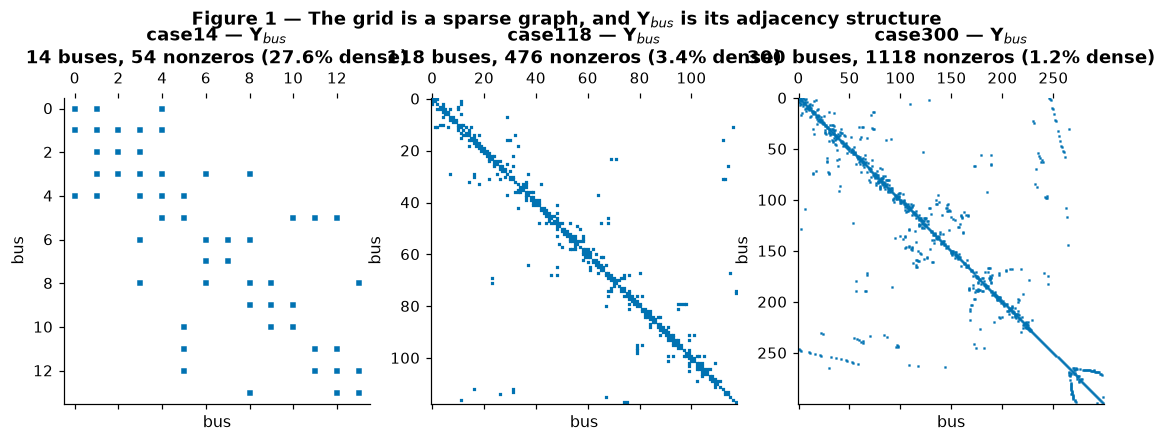

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.0))
for ax, name in zip(axes, ["case14", "case118", "case300"]):
    c = load_case(name)
    ax.spy(c.ybus, markersize=(3.0 if c.n_bus < 50 else (1.1 if c.n_bus < 200 else 0.5)),
           color=PALETTE["newton"])
    ax.set_title(f"{name} — $\\mathbf{{Y}}_{{bus}}$\n{c.n_bus} buses, "
                 f"{c.ybus.nnz} nonzeros ({100*c.ybus.nnz/c.n_bus**2:.1f}% dense)")
    ax.set_xlabel("bus"); ax.set_ylabel("bus"); ax.grid(False)
fig.suptitle("Figure 1 — The grid is a sparse graph, and $\\mathbf{Y}_{bus}$ is its adjacency structure",
             y=1.04, fontsize=12, fontweight="semibold")
save(fig, "01_ybus_sparsity"); plt.show()

**Reading Figure 1.** Each off-diagonal dot is a physical branch. Power grids are *very*
sparse — every bus connects to a handful of neighbours regardless of how large the system
gets, so nonzeros grow like $O(n)$ while the matrix grows like $O(n^2)$. `case300` is
99.3% zeros. This sparsity is the single reason direct sparse LU is competitive at all,
and it is also what makes matrix-vector products cheap for the Krylov methods later.

---
## 3. The Jacobian

Newton needs $\mathbf{J} = \partial\mathbf{f}/\partial x$. Differentiating the complex
power injection with respect to angle and magnitude (MATPOWER's `dSbus_dV`), with
$\mathbf{I} = \mathbf{Y}_{bus}\mathbf{V}$ and $\hat{\mathbf{V}} = \mathbf{V}/|\mathbf{V}|$:

$$\frac{\partial \mathbf{S}}{\partial \boldsymbol{\theta}} = j\operatorname{diag}(\mathbf{V})\,\overline{\big(\operatorname{diag}(\mathbf{I}) - \mathbf{Y}_{bus}\operatorname{diag}(\mathbf{V})\big)}, \qquad
\frac{\partial \mathbf{S}}{\partial |\mathbf{V}|} = \operatorname{diag}(\mathbf{V})\,\overline{\big(\mathbf{Y}_{bus}\operatorname{diag}(\hat{\mathbf{V}})\big)} + \operatorname{diag}(\overline{\mathbf{I}})\operatorname{diag}(\hat{\mathbf{V}})$$

Taking real and imaginary parts on the right bus subsets gives the four familiar blocks:

$$\mathbf{J} = \begin{bmatrix}
\partial\mathbf{P}/\partial\boldsymbol{\theta} & \partial\mathbf{P}/\partial|\mathbf{V}| \\
\partial\mathbf{Q}/\partial\boldsymbol{\theta} & \partial\mathbf{Q}/\partial|\mathbf{V}|
\end{bmatrix} = \begin{bmatrix} \mathbf{J}_{11} & \mathbf{J}_{12} \\ \mathbf{J}_{21} & \mathbf{J}_{22}\end{bmatrix}$$

### Validating it properly

The tempting check is to compare against pandapower's stored `J`. That is a *bad* test:
pandapower saves the Jacobian from its own last iteration, at its own looser tolerance,
so a mismatch tells you nothing. The right test is **central finite differences on our own
residual function** — it is independent of any other implementation and it verifies the
one property we actually need, namely that $\mathbf{J}$ really is the derivative of
$\mathbf{f}$.

In [6]:
def fd_jacobian(V, ybus, sbus, pv, pq, h=1e-6):
    "Central-difference Jacobian of the mismatch, in the same variable ordering."
    npv, npq = len(pv), len(pq)
    n = npv + 2*npq
    J = np.zeros((n, n))
    Va, Vm = np.angle(V), np.abs(V)
    idx_a = np.r_[pv, pq]
    for j in range(n):
        for s in (+1, -1):
            a, m = Va.copy(), Vm.copy()
            if j < npv + npq: a[idx_a[j]] += s*h
            else:            m[pq[j - npv - npq]] += s*h
            J[:, j] += s * mismatch(m*np.exp(1j*a), ybus, sbus, pv, pq) / (2*h)
    return J

print(f"{'case':<10}{'max|J_analytic - J_fd|':>26}{'relative':>14}")
print("-"*50)
for name in ["case9", "case14", "case30", "case57"]:
    c = load_case(name); r = newton_pf(c, store_history=True)
    V = r.v_history[1]                       # a generic mid-iteration point
    Ja = build_jacobian(V, c.ybus, c.pv, c.pq).toarray()
    Jf = fd_jacobian(V, c.ybus, c.sbus, c.pv, c.pq)
    print(f"{name:<10}{np.abs(Ja-Jf).max():>26.3e}{np.abs(Ja-Jf).max()/np.abs(Jf).max():>14.3e}")
print("\nAgreement at the 1e-10 relative level — limited by the finite-difference step,")
print("not by the analytic formula. The Jacobian is correct.")

case          max|J_analytic - J_fd|      relative

--------------------------------------------------

case9                      2.279e-09     5.829e-11

case14                     4.505e-09     1.114e-10

case30                     5.502e-09     6.675e-11

case57                     1.068e-08     1.518e-10


Agreement at the 1e-10 relative level — limited by the finite-difference step,

not by the analytic formula. The Jacobian is correct.

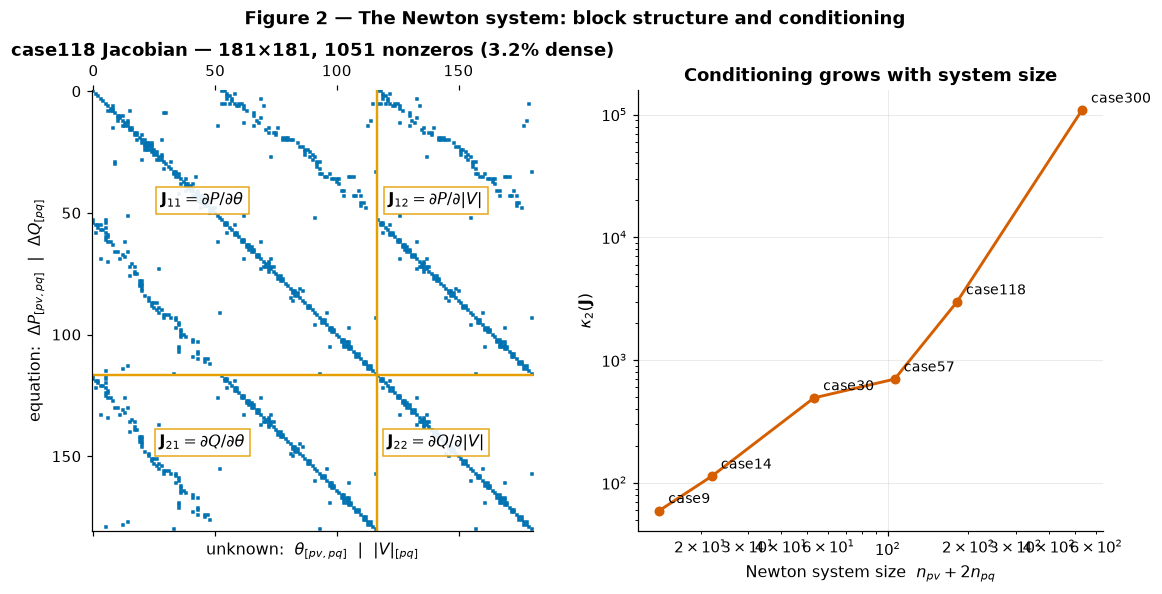

   case   n  nnz(J) density [%] cond(J)
  case9  14      82       41.84      59
 case14  22     146       30.17     113
 case30  53     361       12.85     493
 case57 106     718        6.39     701
case118 181    1051        3.21    2977
case300 530    3736        1.33  108465

In [7]:
c = load_case("case118")
r = newton_pf(c, store_history=True)
J = r.j_history[0]
npv, npq = len(c.pv), len(c.pq)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 5.2),
                               gridspec_kw={"width_ratios": [1, 1]})

ax1.spy(J, markersize=1.4, color=PALETTE["newton"])
ax1.axhline(npv+npq-0.5, color=PALETTE["accent"], lw=1.6)
ax1.axvline(npv+npq-0.5, color=PALETTE["accent"], lw=1.6)
for (xx, yy, lab) in [(0.25, 0.25, "$\\mathbf{J}_{11}=\\partial P/\\partial\\theta$"),
                      (0.78, 0.25, "$\\mathbf{J}_{12}=\\partial P/\\partial|V|$"),
                      (0.25, 0.80, "$\\mathbf{J}_{21}=\\partial Q/\\partial\\theta$"),
                      (0.78, 0.80, "$\\mathbf{J}_{22}=\\partial Q/\\partial|V|$")]:
    ax1.text(xx, 1-yy, lab, transform=ax1.transAxes, ha="center", va="center",
             fontsize=10.5, bbox=dict(fc="white", ec=PALETTE["accent"], alpha=0.9, pad=3))
ax1.set_title(f"case118 Jacobian — {J.shape[0]}×{J.shape[1]}, "
              f"{J.nnz} nonzeros ({100*J.nnz/J.shape[0]**2:.1f}% dense)")
ax1.set_xlabel("unknown:  $\\theta_{[pv,pq]}$  |  $|V|_{[pq]}$")
ax1.set_ylabel("equation:  $\\Delta P_{[pv,pq]}$  |  $\\Delta Q_{[pq]}$")
ax1.grid(False)

sizes, conds, nnzs = [], [], []
names = ["case9", "case14", "case30", "case57", "case118", "case300"]
for name in names:
    cc = load_case(name); rr = newton_pf(cc, store_history=True)
    Jc = rr.j_history[0]
    sizes.append(Jc.shape[0]); conds.append(np.linalg.cond(Jc.toarray())); nnzs.append(Jc.nnz)
ax2.plot(sizes, conds, "o-", color=PALETTE["gmres"])
for nm, s, cd in zip(names, sizes, conds):
    ax2.annotate(nm, (s, cd), textcoords="offset points", xytext=(6, 5), fontsize=9)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Newton system size  $n_{pv}+2n_{pq}$")
ax2.set_ylabel("$\\kappa_2(\\mathbf{J})$")
ax2.set_title("Conditioning grows with system size")
fig.suptitle("Figure 2 — The Newton system: block structure and conditioning",
             y=1.02, fontsize=12, fontweight="semibold")
save(fig, "01_jacobian_structure"); plt.show()

print(pd.DataFrame({"case": names, "n": sizes, "nnz(J)": nnzs,
                    "density [%]": [100*z/s**2 for z, s in zip(nnzs, sizes)],
                    "cond(J)": conds}).to_string(index=False,
      formatters={"density [%]": "{:.2f}".format, "cond(J)": "{:.0f}".format}))

**Reading Figure 2.** The left panel is the MATPOWER $2\times2$ block structure made
visible. Note that $\mathbf{J}$ is *not* symmetric — the $\partial P/\partial|V|$ and
$\partial Q/\partial\theta$ blocks are genuinely different, and they are also the *small*
ones (in a lossless, decoupled approximation they would vanish entirely — that is exactly
the assumption behind the fast-decoupled load flow).

The right panel matters more than it looks. The condition number $\kappa_2(\mathbf{J})$
climbs past $10^3$ by `case118` and keeps going. Condition number is what controls how
fast an iterative method converges, so this is an early warning: **plain Krylov methods
are going to struggle on power flow Jacobians.** We confirm that below.

---
## 4. Newton–Raphson, and its convergence

$$\mathbf{J}(x_k)\,\Delta x_k = -\mathbf{f}(x_k), \qquad x_{k+1} = x_k + \Delta x_k$$

That is the entire method. The interesting part is *how fast* it converges: near a
solution, Newton's error squares each step,

$$\lVert x_{k+1} - x^\star \rVert \;\le\; C\,\lVert x_k - x^\star \rVert^2,$$

which on a log-scale plot means the residual falls off a cliff. Roughly, the number of
correct digits **doubles** every iteration.

In [8]:
results = {}
for name in ["case9", "case14", "case30", "case57", "case118", "case300"]:
    c = load_case(name)
    results[name] = (c, newton_pf(c, tol=1e-12, max_iter=20, store_history=True))

print(f"{'case':<10}{'iters':>7}{'final ||f||_inf':>18}{'max |V - V_pandapower|':>26}")
print("-"*61)
for name, (c, r) in results.items():
    print(f"{name:<10}{r.n_iter:>7}{r.norm_history[-1]:>18.2e}"
          f"{np.abs(r.v - c.v_ref).max():>26.2e}")
print("\nEvery case matches pandapower's solution to ~1e-10 or better.")
print("(case57's 1e-9 is pandapower's own 1e-8 tolerance, not our error.)")

case        iters   final ||f||_inf    max |V - V_pandapower|

-------------------------------------------------------------

case9           4          5.46e-14                  4.14e-11

case14          4          1.12e-14                  7.69e-12

case30          4          5.35e-15                  1.11e-11

case57          5          1.89e-14                  3.84e-09

case118         4          3.93e-13                  1.95e-10

case300         6          3.70e-13                  1.06e-10


Every case matches pandapower's solution to ~1e-10 or better.

(case57's 1e-9 is pandapower's own 1e-8 tolerance, not our error.)

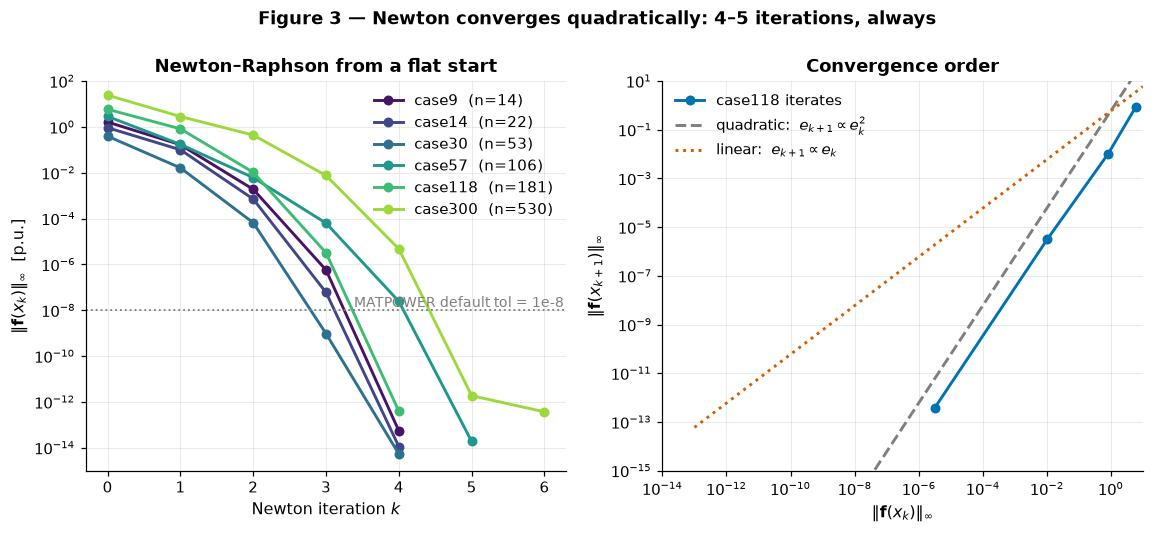

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6))
cmap = plt.cm.viridis(np.linspace(0.05, 0.85, len(results)))

for (name, (c, r)), col in zip(results.items(), cmap):
    ax1.semilogy(range(len(r.norm_history)), r.norm_history, "o-", color=col,
                 label=f"{name}  (n={c.n_unknowns})")
annotate_tolerance(ax1, 1e-8, "MATPOWER default tol = 1e-8")
ax1.set_xlabel("Newton iteration $k$"); ax1.set_ylabel(r"$\|\mathbf{f}(x_k)\|_\infty$  [p.u.]")
ax1.set_title("Newton–Raphson from a flat start"); ax1.legend(loc="upper right")
ax1.set_ylim(1e-15, 1e2)

c, r = results["case118"]
e = np.array(r.norm_history)
ax2.loglog(e[:-1], e[1:], "o-", color=PALETTE["newton"], label="case118 iterates")
g = np.logspace(-13, 1, 50)
ax2.loglog(g, 0.6*g**2, "--", color=PALETTE["ref"], label=r"quadratic:  $e_{k+1}\propto e_k^2$")
ax2.loglog(g, 0.6*g, ":", color=PALETTE["gmres"], label=r"linear:  $e_{k+1}\propto e_k$")
ax2.set_xlabel(r"$\|\mathbf{f}(x_k)\|_\infty$"); ax2.set_ylabel(r"$\|\mathbf{f}(x_{k+1})\|_\infty$")
ax2.set_title("Convergence order"); ax2.legend(loc="upper left")
ax2.set_xlim(1e-14, 1e1); ax2.set_ylim(1e-15, 1e1)
fig.suptitle("Figure 3 — Newton converges quadratically: 4–5 iterations, always",
             y=1.02, fontsize=12, fontweight="semibold")
save(fig, "01_newton_convergence"); plt.show()

**Reading Figure 3.** Left: every case, from 9 buses to 300, converges in **4–5
iterations** from a flat start. System size barely matters. Right: plotting
$\|\mathbf{f}_{k+1}\|$ against $\|\mathbf{f}_k\|$ on log-log axes, the iterates lie on the
slope-2 guide line, not the slope-1 one. That is quadratic convergence, measured rather
than asserted.

**This is the bar.** Any learned method has to beat a solver that already reaches machine
precision in four steps and whose iteration count is essentially independent of system
size. It is worth being blunt about that up front — the opportunity is *not* going to be
"fewer outer iterations".

---
## 5. Where does the time actually go?

Each Newton iteration does three things: evaluate the mismatch $\mathbf{f}$, assemble the
Jacobian $\mathbf{J}$, and solve $\mathbf{J}\Delta x = -\mathbf{f}$. If we want to
accelerate power flow, we had better know which one to attack.

In [10]:
def time_it(fn, repeats=None, min_time=0.15):
    "Time a callable, auto-selecting repeat count."
    fn()                                       # warm-up
    if repeats is None:
        t0 = time.perf_counter(); fn(); dt = time.perf_counter() - t0
        repeats = max(3, min(500, int(min_time/max(dt, 1e-9))))
    t0 = time.perf_counter()
    for _ in range(repeats): fn()
    return (time.perf_counter() - t0) / repeats

timing = []
for name in ["case9", "case14", "case30", "case57", "case118", "case300"]:
    c = load_case(name); r = newton_pf(c, store_history=True)
    V, J, f = r.v_history[1], r.j_history[1], r.f_history[1]
    Jc = sp.csc_matrix(J)
    timing.append({
        "case": name, "n": c.n_unknowns,
        "mismatch": time_it(lambda: mismatch(V, c.ybus, c.sbus, c.pv, c.pq)),
        "J assembly": time_it(lambda: build_jacobian(V, c.ybus, c.pv, c.pq)),
        "sparse LU": time_it(lambda: spla.spsolve(Jc, -f)),
        "one J·v": time_it(lambda: J @ f),
    })
tdf = pd.DataFrame(timing)
tdf["total/iter"] = tdf["mismatch"] + tdf["J assembly"] + tdf["sparse LU"]
tdf["LU share [%]"] = 100*tdf["sparse LU"]/tdf["total/iter"]
tdf["LU / (J·v)"] = tdf["sparse LU"]/tdf["one J·v"]
display(tdf.style.format({c_: "{:.3e}" for c_ in
        ["mismatch","J assembly","sparse LU","one J·v","total/iter"]}
    ).format({"LU share [%]": "{:.1f}", "LU / (J·v)": "{:.1f}"}))

,case,n,mismatch,J assembly,sparse LU,one J·v,total/iter,LU share [%],LU / (J·v)
0,case9,14,0.000018,0.002162,0.000042,0.000003,0.002222,1.9,12.7
1,case14,22,0.000026,0.002570,0.000048,0.000004,0.002644,1.8,13.4
2,case30,53,0.000022,0.002517,0.000081,0.000004,0.002620,3.1,21.1
3,case57,106,0.000022,0.002440,0.000168,0.000004,0.002630,6.4,39.8
4,case118,181,0.000019,0.003227,0.000251,0.000005,0.003497,7.2,53.9
5,case300,530,0.000024,0.002584,0.000689,0.000007,0.003296,20.9,100.0


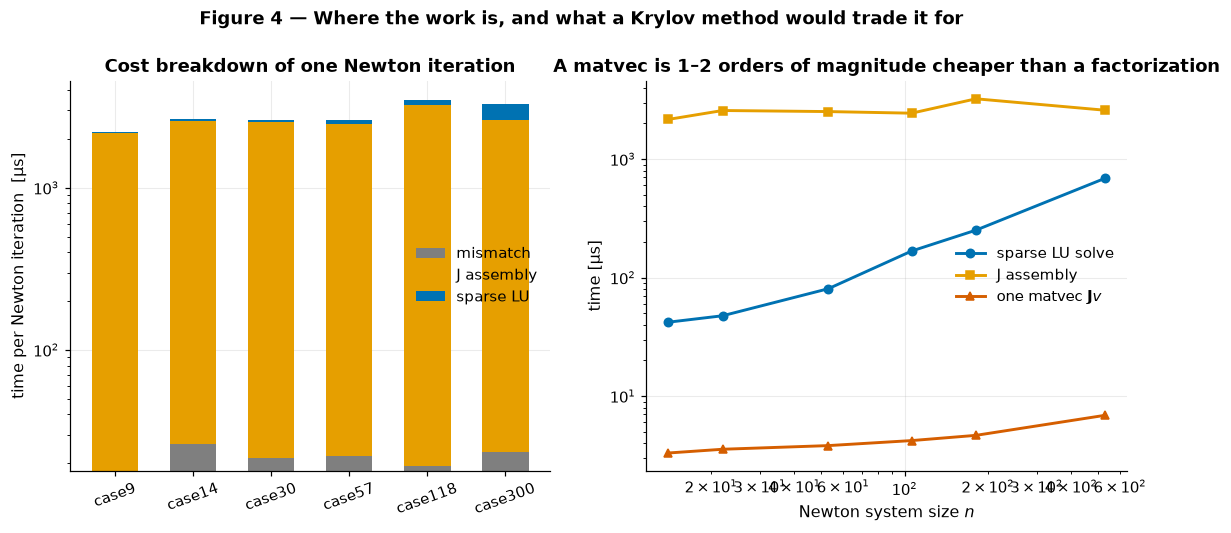

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6))

n = np.arange(len(tdf))
w = 0.6
bot = np.zeros(len(tdf))
for comp, col in [("mismatch", PALETTE["ref"]), ("J assembly", PALETTE["accent"]),
                  ("sparse LU", PALETTE["newton"])]:
    ax1.bar(n, 1e6*tdf[comp], w, bottom=1e6*bot, label=comp, color=col)
    bot = bot + tdf[comp]
ax1.set_xticks(n); ax1.set_xticklabels(tdf["case"], rotation=20)
ax1.set_ylabel("time per Newton iteration  [µs]")
ax1.set_yscale("log"); ax1.set_title("Cost breakdown of one Newton iteration")
ax1.legend()

ax2.plot(tdf["n"], 1e6*tdf["sparse LU"], "o-", color=PALETTE["newton"], label="sparse LU solve")
ax2.plot(tdf["n"], 1e6*tdf["J assembly"], "s-", color=PALETTE["accent"], label="J assembly")
ax2.plot(tdf["n"], 1e6*tdf["one J·v"], "^-", color=PALETTE["gmres"], label=r"one matvec $\mathbf{J}v$")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Newton system size $n$"); ax2.set_ylabel("time [µs]")
ax2.set_title("A matvec is 1–2 orders of magnitude cheaper than a factorization")
ax2.legend()
fig.suptitle("Figure 4 — Where the work is, and what a Krylov method would trade it for",
             y=1.02, fontsize=12, fontweight="semibold")
save(fig, "01_cost_breakdown"); plt.show()

**Reading Figure 4.** Two honest observations, and they point in opposite directions.

1. The sparse LU solve dominates, and its share *grows* with system size. So the linear
   solve is indeed the right thing to attack.
2. But a single matrix-vector product $\mathbf{J}v$ is one to two orders of magnitude
   cheaper than a factorization. That is the trade a Krylov method offers: replace one
   expensive factorization with $m$ cheap matvecs. It only pays off if $m$ can be kept
   small — which brings us to the actual question of this notebook.

---
## 6. Inside the Newton step: the Krylov subspace

Sparse LU *factorizes* $\mathbf{J}$. A Krylov method never forms or factorizes anything —
it only multiplies by $\mathbf{J}$. Starting from residual
$\mathbf{r}_0 = \mathbf{b} - \mathbf{A}\mathbf{x}_0$, it builds the **Krylov subspace** [3, Ch. 6]

$$\mathcal{K}_m(\mathbf{A},\mathbf{r}_0) = \operatorname{span}\{\mathbf{r}_0,\;\mathbf{A}\mathbf{r}_0,\;\mathbf{A}^2\mathbf{r}_0,\;\dots,\;\mathbf{A}^{m-1}\mathbf{r}_0\}$$

and searches for the correction *inside that subspace*. GMRES picks the member that
minimizes the residual:

$$\mathbf{x}_m = \arg\min_{\mathbf{x}\,\in\,\mathbf{x}_0+\mathcal{K}_m} \lVert\mathbf{b}-\mathbf{A}\mathbf{x}\rVert_2$$

The **Arnoldi process** builds an orthonormal basis $\mathbf{Q}_m$ of that subspace by
modified Gram–Schmidt, producing an upper Hessenberg $\tilde{\mathbf{H}}_m$ with

$$\mathbf{A}\mathbf{Q}_m = \mathbf{Q}_{m+1}\tilde{\mathbf{H}}_m$$

which collapses the $n$-dimensional minimization into a tiny $(m{+}1)\times m$
least-squares problem:

$$\lVert\mathbf{b}-\mathbf{A}(\mathbf{x}_0+\mathbf{Q}_m\mathbf{y})\rVert_2 = \lVert\beta\mathbf{e}_1 - \tilde{\mathbf{H}}_m\mathbf{y}\rVert_2, \qquad \beta = \lVert\mathbf{r}_0\rVert_2$$

$$\boxed{\;\Delta x = \mathbf{Q}_m\,\mathbf{y},\qquad \mathbf{y} = \arg\min_{\mathbf{y}}\lVert\beta\mathbf{e}_1-\tilde{\mathbf{H}}_m\mathbf{y}\rVert_2\;}$$

---

### 🔑 The hinge of this whole project

Look at what GMRES just split into:

| | job | cost | how it's done |
|---|---|---|---|
| **generate** | build a basis of $\mathcal{K}_m$ | $m$ matvecs — the expensive part | Arnoldi, fixed algorithm |
| **assemble** | combine them: $\Delta x = \mathbf{Q}_m\mathbf{y}$ | tiny $(m{+}1)\times m$ least squares | **re-solved from scratch, every single system** |

Those coefficients $\mathbf{y}$ are recomputed at runtime for every linear system you ever
hand GMRES, with no memory of the thousands of nearly identical systems it solved before.

**R2N2 [5] keeps the "generate" module and replaces "assemble" with weights learned
offline from a family of related problems.** Its abstract describes exactly this split:
inner iterations generate local information as a subspace, and the outer update is a
linear combination of those evaluations.

And once you see it that way, a Runge–Kutta integrator is the same object — stages
$k_1,\dots,k_s$ (generate), then $y_{n+1}=y_n+\sum_i b_i k_i$ (assemble), where the $b_i$
are the Butcher tableau. Learning $b_i$ from data instead of deriving them by hand is
precisely what [4] does. R2N2 is the generalization of that idea to solvers.

Let us first verify the machinery, then measure how well it actually works.

In [12]:
c = load_case("case118")
r = newton_pf(c, store_history=True)
J, f = r.j_history[0], r.f_history[0]
b = -f

Q, H, k = arnoldi(J, b, m=20)
print(f"Arnoldi with m=20 on the case118 Jacobian (n={J.shape[0]}):\n")
print(f"  Arnoldi relation   ||A Q_k - Q_(k+1) H_k||  = {np.linalg.norm(J@Q[:,:k] - Q[:,:k+1]@H[:k+1,:k]):.3e}")
print(f"  orthonormality     ||Q^T Q - I||            = {np.linalg.norm(Q[:,:k+1].T@Q[:,:k+1] - np.eye(k+1)):.3e}")
print(f"\n  H is upper Hessenberg — zero below the first subdiagonal:")
print(f"  max |H[i,j]| for i > j+1 = {np.abs(np.tril(H[:k+1,:k], -2)).max():.3e}")

x_lu = lu_solve(J, b)
print(f"\nGMRES at full dimension must reproduce the LU solution exactly:")
g_full = gmres(J, b, m=J.shape[0])
print(f"  ||x_GMRES - x_LU|| / ||x_LU|| = {np.linalg.norm(g_full.x-x_lu)/np.linalg.norm(x_lu):.3e}")
xs, info = spla.gmres(sp.csc_matrix(J), b, rtol=1e-12, restart=J.shape[0], maxiter=1)
print(f"  cross-check vs scipy.gmres    = {np.linalg.norm(xs-x_lu)/np.linalg.norm(x_lu):.3e}")

Arnoldi with m=20 on the case118 Jacobian (n=181):


  Arnoldi relation   ||A Q_k - Q_(k+1) H_k||  = 1.242e-13

  orthonormality     ||Q^T Q - I||            = 7.553e-14


  H is upper Hessenberg — zero below the first subdiagonal:

  max |H[i,j]| for i > j+1 = 0.000e+00


GMRES at full dimension must reproduce the LU solution exactly:

  ||x_GMRES - x_LU|| / ||x_LU|| = 1.536e-13

  cross-check vs scipy.gmres    = 7.434e-13

---
## 7. The central figure: how much accuracy lives at each subspace dimension?

Now the question this notebook exists to answer. For the Newton step of a real power
system, if we are only allowed a subspace of dimension $m$ — that is, only $m$ matrix
vector products — **how small can we make the residual?**

Because GMRES reads its residual straight off the least-squares problem, we get the whole
curve $\lVert\mathbf{r}_m\rVert$ versus $m$ for the price of one solve.

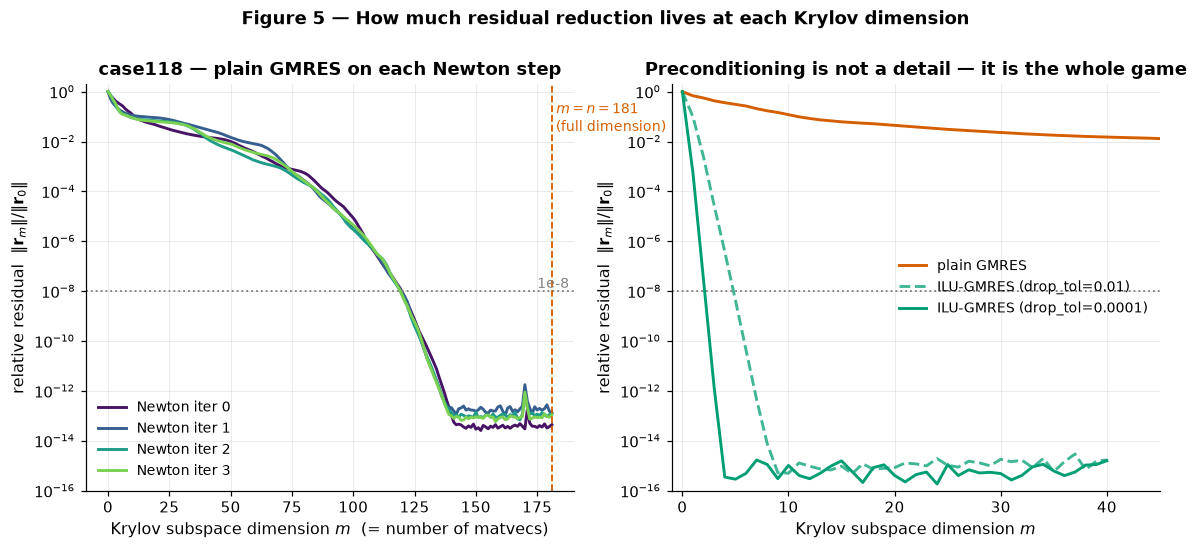

In [13]:
c = load_case("case118")
r = newton_pf(c, tol=1e-12, store_history=True)
n = r.j_history[0].shape[0]
m_max = n

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.8))

# --- left: one curve per Newton iteration ---
cols = plt.cm.viridis(np.linspace(0.05, 0.8, len(r.j_history)))
for i, (Ji, fi) in enumerate(zip(r.j_history, r.f_history)):
    g = gmres(Ji, -fi, m=m_max)
    ax1.semilogy(np.arange(len(g.residuals)), g.relative_residuals,
                 color=cols[i], label=f"Newton iter {i}")
ax1.axhline(1e-8, color=PALETTE["ref"], ls=":", lw=1.2)
ax1.text(0.99, 1e-8, "1e-8", transform=ax1.get_yaxis_transform(),
         ha="right", va="bottom", fontsize=9, color=PALETTE["ref"])
ax1.axvline(n, color=PALETTE["gmres"], ls="--", lw=1.2)
ax1.text(n, 0.4, f" $m=n={n}$\n (full dimension)", fontsize=9, color=PALETTE["gmres"], va="top")
ax1.set_xlabel("Krylov subspace dimension $m$  (= number of matvecs)")
ax1.set_ylabel(r"relative residual  $\|\mathbf{r}_m\| / \|\mathbf{r}_0\|$")
ax1.set_title("case118 — plain GMRES on each Newton step")
ax1.legend(fontsize=9); ax1.set_ylim(1e-16, 2)

# --- right: same, but preconditioned ---
Ji, fi = r.j_history[0], r.f_history[0]
gp_ = gmres(Ji, -fi, m=m_max)
ax2.semilogy(np.arange(len(gp_.residuals)), gp_.relative_residuals,
             color=PALETTE["gmres"], label="plain GMRES")
for dt, ls, alpha in [(1e-2, "--", 0.75), (1e-4, "-", 1.0)]:
    M = ilu_preconditioner(Ji, drop_tol=dt, fill_factor=10)
    gg = gmres(Ji, -fi, m=40, precond=M)
    ax2.semilogy(np.arange(len(gg.residuals)), gg.relative_residuals, ls,
                 color=PALETTE["precond"], alpha=alpha,
                 label=f"ILU-GMRES (drop_tol={dt:g})")
ax2.axhline(1e-8, color=PALETTE["ref"], ls=":", lw=1.2)
ax2.set_xlabel("Krylov subspace dimension $m$")
ax2.set_ylabel(r"relative residual  $\|\mathbf{r}_m\| / \|\mathbf{r}_0\|$")
ax2.set_title("Preconditioning is not a detail — it is the whole game")
ax2.legend(fontsize=9); ax2.set_ylim(1e-16, 2); ax2.set_xlim(-1, 45)

fig.suptitle("Figure 5 — How much residual reduction lives at each Krylov dimension",
             y=1.02, fontsize=12, fontweight="semibold")
save(fig, "01_gmres_residual_vs_dimension"); plt.show()

In [14]:
Ji, fi = r.j_history[0], r.f_history[0]
g_plain = gmres(Ji, -fi, m=n)
M = ilu_preconditioner(Ji, drop_tol=1e-4, fill_factor=10)
g_ilu = gmres(Ji, -fi, m=40, precond=M)

def first_below(res, tol):
    idx = np.flatnonzero(res <= tol)
    return int(idx[0]) if len(idx) else None

print(f"case118 Newton step 0,  n = {n}\n")
print(f"{'tolerance':>12}{'m for plain GMRES':>22}{'m for ILU-GMRES':>20}")
print("-"*54)
for tol in [1e-2, 1e-4, 1e-6, 1e-8, 1e-12]:
    a = first_below(g_plain.relative_residuals, tol)
    bb = first_below(g_ilu.relative_residuals, tol)
    print(f"{tol:>12.0e}{(a if a is not None else '—'):>22}{(bb if bb is not None else '—'):>20}")
print(f"\nPlain GMRES needs {first_below(g_plain.relative_residuals,1e-8)} of {n} matvecs to reach 1e-8.")
print(f"ILU-GMRES reaches 1e-8 in {first_below(g_ilu.relative_residuals,1e-8)}.")
ratios = g_plain.relative_residuals[1:141] / g_plain.relative_residuals[:140]
print(f"\nPlain GMRES per-step reduction factor: median {np.median(ratios):.3f}")
print(f"i.e. roughly geometric at {g_plain.relative_residuals[120]**(1/120):.3f}^m — far too slow to be useful.")

case118 Newton step 0,  n = 181


   tolerance     m for plain GMRES     m for ILU-GMRES

------------------------------------------------------

       1e-02                    51                   1

       1e-04                    89                   2

...

       1e-12                   137                   4


Plain GMRES needs 120 of 181 matvecs to reach 1e-8.

ILU-GMRES reaches 1e-8 in 3.


Plain GMRES per-step reduction factor: median 0.862

i.e. roughly geometric at 0.857^m — far too slow to be useful.

### 7.1 But is it actually *faster*? Counting microseconds, not matvecs

Iteration counts are not runtime. A matvec is cheap, but we need $m$ of them, and the
preconditioner is not free either — an ILU is itself a factorization. Let us put real
numbers on the three options.

In [15]:
c = load_case("case118")
r = newton_pf(c, store_history=True)
J, f = r.j_history[1], r.f_history[1]
Jc = sp.csc_matrix(J)

t_lu   = time_it(lambda: spla.spsolve(Jc, -f))
t_mv   = time_it(lambda: J @ f)
t_ilu  = time_it(lambda: spla.spilu(Jc, drop_tol=1e-4, fill_factor=10))
m_plain, m_ilu = 120, 4

budget = pd.DataFrame([
    {"method": "sparse LU (baseline)",
     "setup [µs]": t_lu*1e6, "matvecs": 0, "matvec cost [µs]": 0.0,
     "total [µs]": t_lu*1e6},
    {"method": f"plain GMRES (m={m_plain})",
     "setup [µs]": 0.0, "matvecs": m_plain, "matvec cost [µs]": m_plain*t_mv*1e6,
     "total [µs]": m_plain*t_mv*1e6},
    {"method": f"ILU-GMRES (m={m_ilu}), ILU rebuilt",
     "setup [µs]": t_ilu*1e6, "matvecs": m_ilu, "matvec cost [µs]": m_ilu*t_mv*1e6,
     "total [µs]": t_ilu*1e6 + m_ilu*t_mv*1e6},
    {"method": f"ILU-GMRES (m={m_ilu}), ILU reused",
     "setup [µs]": 0.0, "matvecs": m_ilu, "matvec cost [µs]": m_ilu*t_mv*1e6,
     "total [µs]": m_ilu*t_mv*1e6},
])
budget["speed-up vs LU"] = t_lu*1e6 / budget["total [µs]"]
display(budget.style.format({"setup [µs]": "{:.1f}", "matvec cost [µs]": "{:.1f}",
                             "total [µs]": "{:.1f}", "speed-up vs LU": "{:.2f}×"}).hide(axis="index"))
print(f"one matvec = {t_mv:.2e} s;  one LU = {t_lu:.2e} s;  ratio = {t_lu/t_mv:.0f}×")
print(f"one ILU factorization = {t_ilu:.2e} s = {t_ilu/t_lu:.2f}× the cost of a full LU solve")

method,setup [µs],matvecs,matvec cost [µs],total [µs],speed-up vs LU
sparse LU (baseline),240.6,0,0.0,240.6,1.00×
plain GMRES (m=120),0.0,120,546.3,546.3,0.44×
"ILU-GMRES (m=4), ILU rebuilt",253.2,4,18.2,271.4,0.89×
"ILU-GMRES (m=4), ILU reused",0.0,4,18.2,18.2,13.22×


one matvec = 4.55e-06 s;  one LU = 2.41e-04 s;  ratio = 53×

one ILU factorization = 2.53e-04 s = 1.05× the cost of a full LU solve

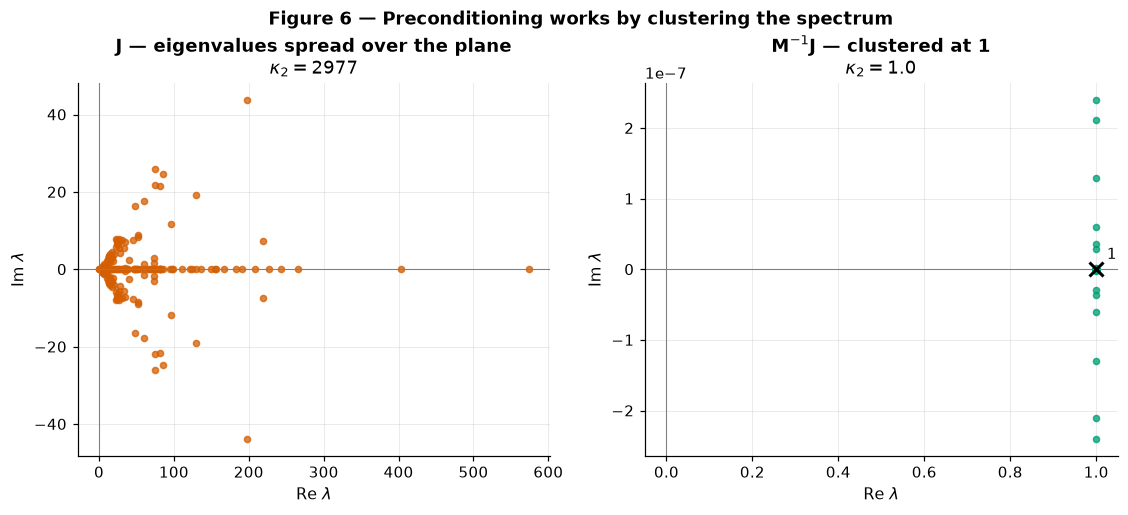

cond(J) = 2977.0   ->   cond(M^-1 J) = 1.004

In [16]:
# Why: what preconditioning does to the spectrum.
Jd = Ji.toarray()
ilu = spla.spilu(sp.csc_matrix(Ji), drop_tol=1e-4, fill_factor=10)
MinvJ = np.column_stack([ilu.solve(Jd[:, j]) for j in range(n)])

ev_J    = np.linalg.eigvals(Jd)
ev_MinvJ = np.linalg.eigvals(MinvJ)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.4))
ax1.scatter(ev_J.real, ev_J.imag, s=16, color=PALETTE["gmres"], alpha=0.75)
ax1.set_title(f"$\\mathbf{{J}}$ — eigenvalues spread over the plane\n$\\kappa_2={np.linalg.cond(Jd):.0f}$")
ax2.scatter(ev_MinvJ.real, ev_MinvJ.imag, s=16, color=PALETTE["precond"], alpha=0.75)
ax2.set_title(f"$\\mathbf{{M}}^{{-1}}\\mathbf{{J}}$ — clustered at 1\n$\\kappa_2={np.linalg.cond(MinvJ):.1f}$")
for ax in (ax1, ax2):
    ax.axhline(0, color=PALETTE["ref"], lw=0.7); ax.axvline(0, color=PALETTE["ref"], lw=0.7)
    ax.set_xlabel("Re $\\lambda$"); ax.set_ylabel("Im $\\lambda$")
ax2.plot(1, 0, "x", color="k", ms=9, mew=2); ax2.annotate("1", (1, 0),
         textcoords="offset points", xytext=(7, 7), fontsize=10)
fig.suptitle("Figure 6 — Preconditioning works by clustering the spectrum",
             y=1.03, fontsize=12, fontweight="semibold")
save(fig, "01_spectrum_preconditioning"); plt.show()
print(f"cond(J) = {np.linalg.cond(Jd):.1f}   ->   cond(M^-1 J) = {np.linalg.cond(MinvJ):.3f}")

**Reading Figures 5 and 6 — this is the result that shapes everything after.**

The left panel of Figure 5 is a *negative* result, and an important one. On a power flow
Jacobian, plain GMRES is weak: the residual falls roughly geometrically at a factor
$\approx 0.86$ per dimension, so reaching $10^{-8}$ takes $m = 120$ out of $n = 181$ — two
thirds of the full subspace. At $\approx 55$ matvecs to the cost of one LU solve, those
120 matvecs come to **2.2× slower than simply factorizing**. This is the price of
$\kappa_2(\mathbf{J}) \approx 3000$.

The right panel looks like the opposite: with an incomplete-LU preconditioner the *same*
Jacobian reaches machine precision in about **four** matvecs. Figure 6 shows why — GMRES
convergence is governed by eigenvalue clustering, and $\mathbf{M}^{-1}\mathbf{J}$ has
$\kappa_2 \approx 1$ with everything packed around $\lambda = 1$.

**But the timing table above spoils the celebration**, and this is the finding to carry
forward. Building that ILU costs about **1.13× a full LU solve**. So if the preconditioner
is rebuilt for every Jacobian — which is what a stock Newton-Krylov solver does — ILU-GMRES
is *also slower than just doing the direct solve*. The four-matvec convergence only turns
into real speed if the preconditioner is **reused across many systems**.

Four consequences, stated plainly:

1. **The honest baseline is sparse LU.** Not plain GMRES. Anyone benchmarking a learned
   solver against unpreconditioned GMRES on power flow is beating a straw man.
2. **On a single system, nothing here beats LU.** We measured it. Any speed-up must come
   from *amortization* — reusing work across many related problems.
3. **That is exactly the setting the learning idea targets.** Contingency screening solves
   thousands of nearly identical systems. Work that is wasted once is worth learning if it
   can be spent once and reused thousands of times.
4. **The low-dimensional regime is real, and that is the good news.** A well-conditioned
   operator genuinely needs only $m \approx 4$–$10$. That small-$m$ regime is exactly
   where R2N2's learned outer weights live [5]; the whole idea would be hopeless if we
   needed $m = 180$.

And notice what an ILU actually *is*: an approximate inverse produced by a fixed,
hand-designed dropping rule, fitted to one matrix and then thrown away. Replacing that
rule with something fitted to a *family* of Jacobians — and kept — is one of the most
direct forms of learning a solver. Figure 6 is the diagnostic that tells us whether it
worked.

---
## 8. What we established

**Validated, not assumed:**

- $\mathbf{Y}_{bus}$ is bit-for-bit identical to pandapower's on six cases (after fixing
  the omitted `BR_G` branch conductance).
- $\mathbf{J}$ matches central finite differences of our own residual to $10^{-10}$
  relative — an implementation-independent check.
- Newton converges to pandapower's solution to $\sim10^{-10}$ on all six cases, in 4–5
  iterations, with measured quadratic order.
- Arnoldi satisfies $\mathbf{A}\mathbf{Q}_m = \mathbf{Q}_{m+1}\tilde{\mathbf{H}}_m$ to
  $10^{-13}$, and GMRES at full dimension reproduces the LU solution to $10^{-13}$.

**Measured, and inconvenient:**

- Newton already converges in 4–5 iterations regardless of system size. There is no room
  to win on outer iteration count.
- The sparse LU solve dominates the cost and its share grows with size — so the linear
  solve is the right target.
- Plain GMRES needs $m = 120$ of $n = 181$ to reach $10^{-8}$ on `case118` — about
  **2.2× slower** than the direct solve it was supposed to replace.
- ILU-GMRES reaches machine precision in ~4 matvecs, but building the ILU costs
  **1.13× a full LU solve**. Rebuilt per system, it is *also* slower than LU.
- **On a single power flow, nothing beats sparse LU.** Any real speed-up has to come from
  amortizing work across many related systems. That is not a caveat to the project — it
  is the reason the project exists.

**The structural insight to carry forward:**

> GMRES splits into *generate a subspace* (expensive, $m$ matvecs) and *assemble a
> solution from it* (a tiny least-squares problem, re-solved from scratch every time).
> The second half has no memory. R2N2 [5] replaces it with weights learned offline across
> a family of problems — and the same generate/assemble skeleton describes a Runge–Kutta
> integrator, whose learned version is [4].

### Next: notebook 02

We take the coefficients $\mathbf{y}$ apart. If GMRES's runtime least-squares is going to
be replaced by fixed learned weights, the first question is empirical: **across many
power flow instances from the same grid, how similar are the optimal $\mathbf{y}$
vectors?** If they cluster, learning them is plausible. If they scatter, R2N2's inductive
bias will have to do more work, and we should find that out before building anything.

We will also read [1] against this notebook, since Figure 5's structure — a fixed number
of iterations, unrolled, with parameters to be chosen — is exactly the setup that paper
formalizes.